# Avito Text Orientation — Exploratory Data Analysis

В этом ноутбуке проводится первичный анализ тестового набора изображений:

- количество изображений;
- размеры;
- количество каналов;
- типы данных;
- диапазон значений пикселей;
- среднее и стандартное отклонение;
- соотношение сторон;
- визуальная проверка случайной выборки.

Тестовый набор содержит изображения текстовых crop'ов, для которых
исходная разметка ориентации не предоставляется.

In [2]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

## Dataset

Перед запуском необходимо разместить изображения в:

`data/images/`

Данные соревнования не включены в репозиторий.

In [7]:
IMG_DIR = Path('D:\\it\\avito_test\\test\\images')
files = sorted(IMG_DIR.glob("*.png"))

rows = []

for path in files:
    with Image.open(path) as im:
        arr = np.asarray(im)

        rows.append({
            "image_id": path.stem,
            "width": im.width,
            "height": im.height,
            "channels": len(im.getbands()),
            "dtype": arr.dtype,
            "min": arr.min(),
            "max": arr.max(),
            "mean": arr.mean(),
            "std": arr.std(),
        })

df = pd.DataFrame(rows)

print("Количество:", len(df))
print()
print(df.describe())
print()
print(df["channels"].value_counts())

Количество: 20000

              width        height  channels           min           max  \
count  20000.000000  20000.000000   20000.0  20000.000000  20000.000000   
mean     357.603600     64.398150       3.0     23.607950    238.376300   
std      318.933591     59.337019       0.0     35.436374     30.063762   
min       25.000000     10.000000       3.0      0.000000     27.000000   
25%      129.000000     27.000000       3.0      0.000000    232.000000   
50%      238.000000     42.000000       3.0      6.000000    255.000000   
75%      479.250000     76.000000       3.0     36.000000    255.000000   
max     1599.000000    492.000000       3.0    238.000000    255.000000   

               mean           std  
count  20000.000000  20000.000000  
mean     140.300492     53.779130  
std       52.071866     20.576696  
min        5.745679      2.563903  
25%       99.655878     38.438930  
50%      141.273955     52.832295  
75%      183.682677     68.311704  
max      252.2646

In [8]:
print("Размеры:")
print(df[["width", "height"]].describe())

print("\nСоотношение сторон:")
print((df["width"] / df["height"]).describe())

Размеры:
              width        height
count  20000.000000  20000.000000
mean     357.603600     64.398150
std      318.933591     59.337019
min       25.000000     10.000000
25%      129.000000     27.000000
50%      238.000000     42.000000
75%      479.250000     76.000000
max     1599.000000    492.000000

Соотношение сторон:
count    20000.000000
mean         6.220858
std          4.267151
min          0.720930
25%          3.503241
50%          4.894899
75%          7.518636
max         49.666667
dtype: float64


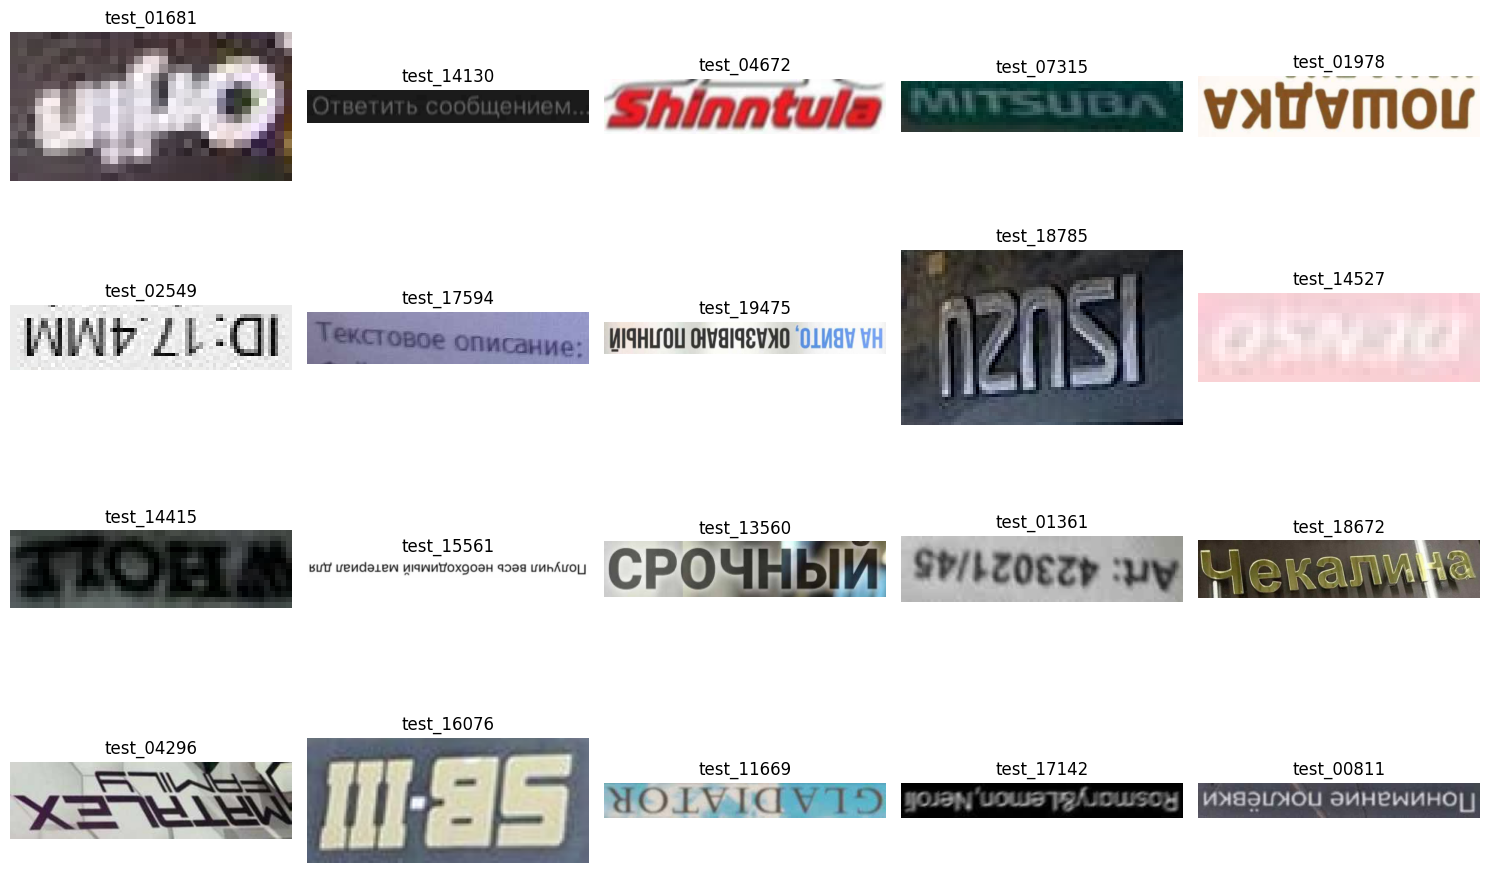

In [ ]:
import matplotlib.pyplot as plt
import random

random.seed(42)

sample = random.sample(files, min(20, len(files)))

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for ax, path in zip(axes.flat, sample):
    with Image.open(path) as img:
        ax.imshow(img)

    ax.set_title(path.stem, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## EDA summary

В датасете 20 000 изображений.

Изображения имеют существенно различающиеся размеры и соотношения сторон,
поэтому перед обучением используется resize с сохранением aspect ratio
и padding до фиксированного размера.

Изображения представлены в RGB и имеют широкий диапазон размеров.
Визуальная проверка показывает, что основным содержимым изображений
является текст, при этом встречаются различные шрифты, размеры,
языки и низкоразрешённые crop'ы.

Поскольку исходные labels отсутствуют, для обучения используются
синтетические пары исходного изображения и его поворота на 180°.